# SIFT

In [1]:
import matplotlib.pyplot as plt

from skimage.feature import hog
from skimage import exposure
import skimage.io as io
import numpy as np
from skimage.color import rgb2gray

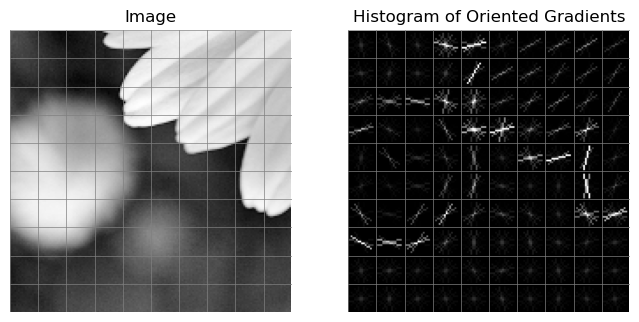

In [2]:
# Taille des fenêtres
L = 16

# Nombre de fenêtres
K = 10

# Image originale
img = io.imread("../_static/figs/daisy.png")
img = rgb2gray(img)
img = img[:L*K, :L*K]

# Histogramme des gradients
fd, hog_image = hog(
    img,
    orientations=8,
    pixels_per_cell=(L, L),
    cells_per_block=(1, 1),
    visualize=True,
)
hog_image = (hog_image - hog_image.min()) / (hog_image.max() - hog_image.min())
hog_image = exposure.rescale_intensity(hog_image, in_range=(0, 0.5))
N = len(img)

# Affichage
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)
axs[0].imshow(img, "gray")
axs[0].set_title('Image')
axs[0].axis('off')
axs[1].imshow(hog_image, "gray")
axs[1].set_title('Histogram of Oriented Gradients')
axs[1].axis('off')
axs[1].set_xlim(0, L*K)
axs[1].set_ylim(0, L*K)

# Grille
for k in range(2):
    for n in range(0,N+1,L):
        axs[k].axvline(n, color="gray", linewidth=.5)
    for n in range(0,N+1,L):
        axs[k].axhline(n, color="gray", linewidth=.5)

plt.savefig("sift-hog.svg", bbox_inches="tight")
plt.show()

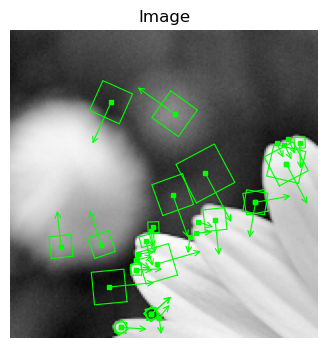

In [3]:
from skimage.feature import match_descriptors, plot_matched_features, SIFT

# SIFT sur l'image
descriptor_extractor = SIFT()
descriptor_extractor.detect_and_extract(img)
keypoints = descriptor_extractor.keypoints
descriptors = descriptor_extractor.descriptors
orientations = descriptor_extractor.orientations
octaves = descriptor_extractor.octaves

# Affichage
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(img, "gray")
ax.set_title('Image')
ax.axis('off')
for k in range(len(orientations)):
    y0, x0 = keypoints[k,:]
    r = 10 + octaves[k]*5.
    y1 = y0 + r*np.cos(orientations[k])
    x1 = x0 + r*np.sin(orientations[k])
    ax.plot(x0, y0, 's', color='lime', markersize=3)
    ax.annotate("", xytext=(x0, y0), xy=(x1, y1), arrowprops=dict(arrowstyle="->", color='lime', linewidth=.8))
plt.savefig("sift-keypoints.svg", bbox_inches="tight")

# Avec les fenêtres
for k in range(len(orientations)):
    yc, xc = keypoints[k,:]
    r = octaves[k]*4.
    a = orientations[k]
    x0, y0 = xc + r*np.sin(a-1*np.pi/4) , yc + r*np.cos(a-1*np.pi/4)
    x1, y1 = xc + r*np.sin(a-3*np.pi/4) , yc + r*np.cos(a-3*np.pi/4)
    x2, y2 = xc + r*np.sin(a-5*np.pi/4) , yc + r*np.cos(a-5*np.pi/4)
    x3, y3 = xc + r*np.sin(a-7*np.pi/4) , yc + r*np.cos(a-7*np.pi/4)
    ax.plot([x0, x1, x2, x3, x0], [y0, y1, y2, y3, y0], color='lime', linewidth=.8)
plt.savefig("sift-keypoints-and-windows.svg", bbox_inches="tight")

plt.show()

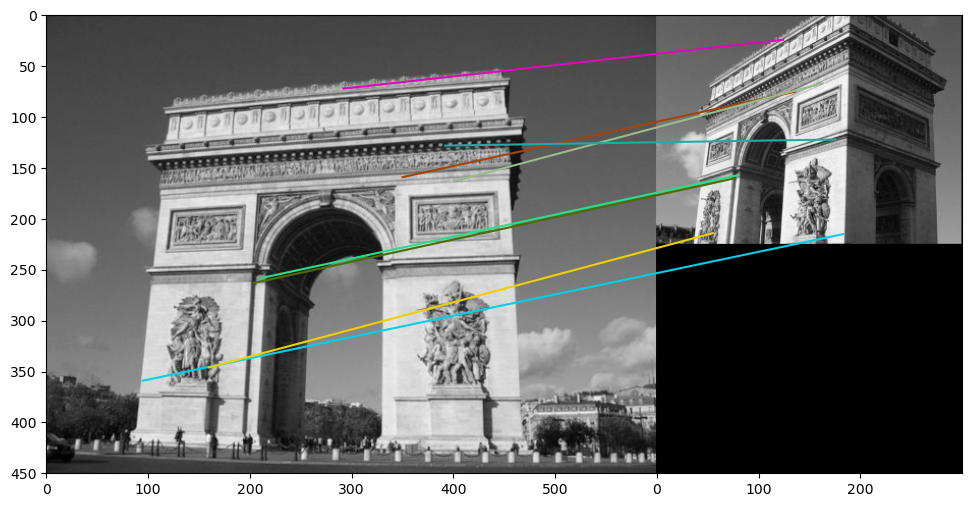

In [28]:
# https://www.ipol.im/pub/art/2014/82/
# https://demo.ipol.im/demo/82/result?key=9B77A900263127E004EE66C298FC04E2

# SIFT
descriptor_extractor = SIFT()

# Image 1
img1 = io.imread('arc1.png')
descriptor_extractor.detect_and_extract(img1)
keypoints1 = descriptor_extractor.keypoints
descriptors1 = descriptor_extractor.descriptors

# image 2
img2 = io.imread('arc2.png')
descriptor_extractor.detect_and_extract(img2)
keypoints2 = descriptor_extractor.keypoints
descriptors2 = descriptor_extractor.descriptors

# Matching
matches = match_descriptors(descriptors1, descriptors2, max_ratio=.6)

# Affichage
plt.figure(figsize=(10, 5))
plot_matched_features(
    img1,
    img2,
    keypoints0=keypoints1,
    keypoints1=keypoints2,
    matches=matches,
    # matches_color='#0f0',
    only_matches=True,
    ax=plt.gca(),
)
plt.tight_layout()
plt.xlim(0, img1.shape[1] + img2.shape[1])
plt.xticks( ticks=range(0, img1.shape[1] + img2.shape[1], 100), labels=[0, 100, 200, 300, 400, 500, 0, 100, 200])
plt.savefig("sift-arc.svg", bbox_inches="tight")
plt.show()